In [1]:
import os
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import importlib
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import (BaseCallback, CheckpointCallback, CallbackList)
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.utils import set_random_seed
import modified_pong_env
import pong_baselines
from modified_pong_env import ModifiedPongEnv
from pong_baselines import action_heuristic_predictive, run_all_baselines

SEED = 2026
N_ACTION_BINS = 21
MAX_EPISODE_DECISIONS = 50
TOTAL_TIMESTEPS = 500_000
EVAL_FREQ = 10_000
N_EVAL_EPISODES_CALLBACK = 100
N_FINAL_EVAL_EPISODES = 300


RESULTS_ROOT = "new_results"
TABLE_DIR = os.path.join(RESULTS_ROOT, tables")
FIG_DIR = os.path.join(RESULTS_ROOT,"figures")

os.makedirs(RESULTS_ROOT, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    set_random_seed(seed)

set_all_seeds(SEED)

In [2]:
# environment builders
def make_train_env(seed=SEED, include_predicted_return_y=True, reward_mode="shaped", monitor_filename=None):
    env = ModifiedPongEnv(
        n_action_bins=N_ACTION_BINS,
        render_mode=None,
        max_episode_decisions=MAX_EPISODE_DECISIONS,
        include_predicted_return_y=include_predicted_return_y,
        reward_mode=reward_mode,
    )

    if monitor_filename is not None: env = Monitor(env,filename=monitor_filename)
    else: env = Monitor(env)
    env.reset(seed=seed)
    env.action_space.seed(seed)
    return env

def make_eval_env(render=False, include_predicted_return_y=True, reward_mode="shaped"):
    render_mode = "human" if render else None
    env = ModifiedPongEnv(
        n_action_bins=N_ACTION_BINS,
        render_mode=render_mode,
        max_episode_decisions=MAX_EPISODE_DECISIONS,
        include_predicted_return_y=include_predicted_return_y,
        reward_mode=reward_mode,
    )

    return env


# PPO eval
def evaluate_ppo_model(
    model,
    n_episodes=200,
    seed_offset=20_000,
    deterministic=True,
    render=False,
    include_predicted_return_y=True,
    reward_mode="shaped",
):
    env = make_eval_env(
        render=render,
        include_predicted_return_y=include_predicted_return_y,
        reward_mode=reward_mode,
    )

    records = []

    for episode in range(n_episodes):
        obs, info = env.reset(seed=seed_offset + episode)
        terminated = False
        truncated = False
        total_reward = 0.0
        steps = 0

        while not (terminated or truncated):
            action, _ = model.predict(
                obs,
                deterministic=deterministic,
            )

            action = int(np.asarray(action).item())
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            steps += 1

        records.append(
            {
                "episode": episode,
                "reward": total_reward,
                "win": 1 if info["right_score"] > info["left_score"] else 0,
                "loss": 1 if info["left_score"] > info["right_score"] else 0,
                "steps": steps,
                "right_score": info["right_score"],
                "left_score": info["left_score"],
                "score_diff": info["score_diff"],
                "frames": info["total_frames"],
                "rally_hits": info["rally_hits"],
                "decision_count": info["decision_count"],
                "truncated": truncated,
                "truncation_reason": info.get("truncation_reason", None),
                "last_right_hit_offset": info["last_right_hit_offset"],
                "last_right_speed_multiplier": info["last_right_speed_multiplier"],
                "last_right_outgoing_speed": info["last_right_outgoing_speed"],
                "final_ball_speed": info["current_ball_speed"],
                "last_left_outgoing_speed": info["last_left_outgoing_speed"],
                "successful_agent_returns": info["successful_agent_returns"],
                "last_selected_target_y": info["last_selected_target_y"],
                "last_predicted_return_y": info["last_predicted_return_y"],
                "last_target_alignment_error": info["last_target_alignment_error"],
                "last_target_alignment_reward": info["last_target_alignment_reward"],
                "cumulative_target_alignment_reward": info[
                    "cumulative_target_alignment_reward"
                ],
            }
        )

    env.close()
    return pd.DataFrame(records)


def summarize_ppo_results(name, df):
    return {
        "policy": name,
        "episodes": len(df),
        "mean_reward": df["reward"].mean(),
        "win_rate": df["win"].mean(),
        "loss_rate": df["loss"].mean(),
        "mean_score_diff": df["score_diff"].mean(),
        "mean_steps": df["steps"].mean(),
        "mean_rally_hits": df["rally_hits"].mean(),
        "truncation_rate": df["truncated"].mean(),
        "mean_final_hit_offset": df["last_right_hit_offset"].mean(),
        "mean_final_speed_multiplier": df["last_right_speed_multiplier"].mean(),
        "mean_final_outgoing_speed": df["last_right_outgoing_speed"].mean(),
        "mean_final_ball_speed": df["final_ball_speed"].mean(),
        "mean_last_left_outgoing_speed": df["last_left_outgoing_speed"].mean(),
        "mean_successful_agent_returns": df["successful_agent_returns"].mean(),
        "mean_final_target_alignment_error": df["last_target_alignment_error"].mean(),
        "mean_final_target_alignment_reward": df["last_target_alignment_reward"].mean(),
        "mean_cumulative_target_alignment_reward": df["cumulative_target_alignment_reward"].mean(),
    }


# Periodic callback eval
class PeriodicPPOEvaluationCallback(BaseCallback):
    def __init__(
        self,
        eval_freq=10_000,
        n_eval_episodes=100,
        seed_offset=50_000,
        best_model_dir="best",
        include_predicted_return_y=True,
        reward_mode="shaped",
        verbose=1,
    ):
        super().__init__(verbose)
        self.eval_freq = eval_freq
        self.n_eval_episodes = n_eval_episodes
        self.seed_offset = seed_offset
        self.best_model_dir = best_model_dir
        self.include_predicted_return_y = include_predicted_return_y
        self.reward_mode = reward_mode
        os.makedirs(self.best_model_dir, exist_ok=True)
        self.evaluation_history = []
        self.best_win_rate = -np.inf
        self.best_mean_reward = -np.inf
        self.best_timestep = None

    def _on_step(self):
        if self.num_timesteps % self.eval_freq == 0:
            eval_df = evaluate_ppo_model(
                model=self.model,
                n_episodes=self.n_eval_episodes,
                seed_offset=self.seed_offset,
                deterministic=True,
                render=False,
                include_predicted_return_y=self.include_predicted_return_y,
                reward_mode=self.reward_mode,
            )

            summary = summarize_ppo_results(name="ppo_eval", df=eval_df)
            summary["timesteps"] = self.num_timesteps
            self.evaluation_history.append(summary)
            current_win_rate = summary["win_rate"]
            current_mean_reward = summary["mean_reward"]

            improved = (
                current_win_rate > self.best_win_rate
                or (
                    current_win_rate == self.best_win_rate
                    and current_mean_reward > self.best_mean_reward
                )
            )

            if improved:
                self.best_win_rate = current_win_rate
                self.best_mean_reward = current_mean_reward
                self.best_timestep = self.num_timesteps
                best_model_path = os.path.join(
                    self.best_model_dir,
                    "best_by_win_rate",
                )

                self.model.save(best_model_path)
                best_summary_df = pd.DataFrame([summary])
                best_summary_df.to_csv(os.path.join(self.best_model_dir, "best_summary.csv"), index=False)

                if self.verbose:
                    print(
                        f"[New best model at {self.num_timesteps:>7} steps] "
                        f"win_rate={current_win_rate:.3f}, "
                        f"mean_reward={current_mean_reward:.3f}"
                    )

            if self.verbose:
                print(
                    f"[Evaluation at {self.num_timesteps:>7} steps] "
                    f"mean_reward={summary['mean_reward']:.3f}, "
                    f"win_rate={summary['win_rate']:.3f}, "
                    f"loss_rate={summary['loss_rate']:.3f}, "
                    f"mean_steps={summary['mean_steps']:.2f}"
                )

        return True

In [3]:
# PPO compare
EXPERIMENTS = {
    "ppo_terminal": {
        "report_label": "PPO-Terminal",
        "reward_mode": "terminal",
        "include_predicted_return_y": False,
    },
    "ppo_shaped": {
        "report_label": "PPO-Shaped",
        "reward_mode": "shaped",
        "include_predicted_return_y": False,
    },
    "ppo_shaped_return_y": {
        "report_label": "PPO-Shaped+ReturnY",
        "reward_mode": "shaped",
        "include_predicted_return_y": True,
    },
}


def build_experiment_paths(experiment_key):
    experiment_root = os.path.join(RESULTS_ROOT, experiment_key)
    paths = {
        "root": experiment_root,
        "models": os.path.join(experiment_root, "models"),
        "logs": os.path.join(experiment_root, "logs"),
        "best": os.path.join(experiment_root, "best"),
    }

    for path in paths.values():  os.makedirs(path, exist_ok=True)
    return paths


def train_and_evaluate_experiment(experiment_key, experiment_cfg):
    report_label = experiment_cfg["report_label"]
    reward_mode = experiment_cfg["reward_mode"]
    include_predicted_return_y = experiment_cfg["include_predicted_return_y"]
    paths = build_experiment_paths(experiment_key)
    print("\n" + "=" * 90)
    print(f"Training experiment: {report_label}")
    print(f"reward_mode={reward_mode}")
    print(f"include_predicted_return_y={include_predicted_return_y}")
    print("=" * 90)

    raw_env = ModifiedPongEnv(
        n_action_bins=N_ACTION_BINS,
        render_mode=None,
        max_episode_decisions=MAX_EPISODE_DECISIONS,
        include_predicted_return_y=include_predicted_return_y,
        reward_mode=reward_mode,
    )

    check_env(raw_env, warn=True)
    obs_check, info_check = raw_env.reset(seed=SEED)
    print(f"{report_label}: observation shape = {obs_check.shape}")
    raw_env.close()

    train_env = make_train_env(
        seed=SEED,
        include_predicted_return_y=include_predicted_return_y,
        reward_mode=reward_mode,
        monitor_filename=os.path.join(
            paths["logs"],
            "train_monitor",
        ),
    )

    model = PPO(
        policy="MlpPolicy",
        env=train_env,
        learning_rate=2e-4,
        n_steps=2048,
        batch_size=256,
        n_epochs=10,
        gamma=0.99,
        gae_lambda=0.95,
        clip_range=0.20,
        ent_coef=0.0,
        vf_coef=0.5,
        max_grad_norm=0.5,
        seed=SEED,
        verbose=1,
        device="cpu",
        tensorboard_log=paths["logs"],
    )

    periodic_eval_callback = PeriodicPPOEvaluationCallback(
        eval_freq=EVAL_FREQ,
        n_eval_episodes=N_EVAL_EPISODES_CALLBACK,
        seed_offset=50_000,
        best_model_dir=paths["best"],
        include_predicted_return_y=include_predicted_return_y,
        reward_mode=reward_mode,
        verbose=1,
    )

    checkpoint_callback = CheckpointCallback(save_freq=50_000, save_path=paths["models"], name_prefix=f"{experiment_key}_checkpoint")
    callbacks = CallbackList([periodic_eval_callback, checkpoint_callback])

    model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=callbacks)
    final_model_path = os.path.join(paths["models"], f"{experiment_key}_final")
    model.save(final_model_path)
    print(f"Saved final model to: {final_model_path}")

    eval_df = evaluate_ppo_model(
        model=model,
        n_episodes=N_FINAL_EVAL_EPISODES,
        seed_offset=100_000,
        deterministic=True,
        render=False,
        include_predicted_return_y=include_predicted_return_y,
        reward_mode=reward_mode,
    )

    summary = summarize_ppo_results(name=experiment_key, df=eval_df)
    summary["report_label"] = report_label
    summary["reward_mode"] = reward_mode
    summary["include_predicted_return_y"] = include_predicted_return_y
    summary_df = pd.DataFrame([summary])
    history_df = pd.DataFrame(periodic_eval_callback.evaluation_history)

    eval_df.to_csv(os.path.join(paths["logs"], f"{experiment_key}_episode_details.csv"), index=False)
    summary_df.to_csv(os.path.join(paths["logs"], f"{experiment_key}_summary.csv"), index=False)
    history_df.to_csv(os.path.join(paths["logs"], f"{experiment_key}_training_history.csv"), index=False)
    train_env.close()
    print("\nFinal evaluation summary:")
    print(summary_df)

    return {
        "model": model,
        "eval_df": eval_df,
        "summary_df": summary_df,
        "history_df": history_df,
        "paths": paths,
    }


PPO_EXPERIMENT_RESULTS = {}
for experiment_key, experiment_cfg in EXPERIMENTS.items():
    PPO_EXPERIMENT_RESULTS[experiment_key] = (
        train_and_evaluate_experiment(
            experiment_key=experiment_key,
            experiment_cfg=experiment_cfg,
        )
    )


Training experiment: PPO-Terminal
reward_mode=terminal
include_predicted_return_y=False
PPO-Terminal: observation shape = (8,)
Using cpu device
Wrapping the env in a DummyVecEnv.
Logging to new_results\ppo_terminal\logs\PPO_12
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1.18     |
|    ep_rew_mean     | -0.74    |
| time/              |          |
|    fps             | 518      |
|    iterations      | 1        |
|    time_elapsed    | 3        |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 1.22         |
|    ep_rew_mean          | -0.7         |
| time/                   |              |
|    fps                  | 484          |
|    iterations           | 2            |
|    time_elapsed         | 8            |
|    total_timesteps      | 4096         |
| train/                  |              |
| 

In [4]:
comparison_parts = []

for experiment_key in EXPERIMENTS:
    result_obj = PPO_EXPERIMENT_RESULTS.get(experiment_key, None)

    if result_obj is not None: summary_df_exp = result_obj["summary_df"].copy()
    else:
        summary_csv = os.path.join(
            RESULTS_ROOT,
            experiment_key,
            "logs",
            f"{experiment_key}_summary.csv",
        )

        if not os.path.exists(summary_csv):
            raise FileNotFoundError(
                f"Missing summary CSV for experiment '{experiment_key}'. "
                f"Expected: {summary_csv}"
            )

        summary_df_exp = pd.read_csv(summary_csv)

    comparison_parts.append(summary_df_exp)


ppo_three_model_comparison_df = pd.concat(comparison_parts, ignore_index=True)
ppo_three_model_comparison_df["policy"] = (ppo_three_model_comparison_df["report_label"])
policy_order = ["PPO-Terminal", "PPO-Shaped", "PPO-Shaped+ReturnY"]
ppo_three_model_comparison_df["policy"] = pd.Categorical(ppo_three_model_comparison_df["policy"], categories=policy_order, ordered=True)
ppo_three_model_comparison_df = (ppo_three_model_comparison_df.sort_values("policy").reset_index(drop=True))

comparison_columns = [
    "policy",
    "episodes",
    "win_rate",
    "loss_rate",
    "mean_reward",
    "mean_score_diff",
    "mean_steps",
    "mean_rally_hits",
    "mean_successful_agent_returns",
    "mean_final_target_alignment_error",
    "mean_final_target_alignment_reward",
]

ppo_three_model_comparison_table = (ppo_three_model_comparison_df[comparison_columns].copy())
comparison_csv = os.path.join(TABLE_DIR,"ppo_three_model_comparison_table.csv")
ppo_three_model_comparison_table.to_csv(comparison_csv, index=False)
print(f"Saved three-model PPO comparison table to: {comparison_csv}")
ppo_three_model_comparison_table

Saved three-model PPO comparison table to: new_results\tables\ppo_three_model_comparison_table.csv


,policy,episodes,win_rate,loss_rate,mean_reward,mean_score_diff,mean_steps,mean_rally_hits,mean_successful_agent_returns,mean_final_target_alignment_error,mean_final_target_alignment_reward
0,PPO-Terminal,300,0.200000,0.800000,-0.600000,-0.600000,1.370000,1.370000,0.370000,154.522767,0.000000
1,PPO-Shaped,300,0.136667,0.863333,-0.687940,-0.726667,1.223333,1.223333,0.223333,162.857269,0.023356
2,PPO-Shaped+ReturnY,300,0.826667,0.173333,0.866037,0.653333,3.390000,3.390000,2.390000,31.998522,0.047582


In [5]:
baseline_summary_df, baseline_details = run_all_baselines(n_episodes=300, max_episode_decisions=50, seed_offset=100_000)
heuristic_summary_df = (baseline_summary_df.loc[baseline_summary_df["policy"] == "heuristic_predictive"].copy())
heuristic_summary_df["policy"] = "Predictive heuristic"
heuristic_summary_df["report_label"] = "Predictive heuristic"
heuristic_summary_df["reward_mode"] = "heuristic"
heuristic_summary_df["include_predicted_return_y"] = True
ppo_report_df = ppo_three_model_comparison_df.copy()
four_model_comparison_df = pd.concat([ppo_report_df, heuristic_summary_df], ignore_index=True)

four_model_policy_order = [
    "PPO-Terminal",
    "PPO-Shaped",
    "PPO-Shaped+ReturnY",
    "Predictive heuristic",
]

four_model_comparison_df["policy"] = pd.Categorical(
    four_model_comparison_df["policy"],
    categories=four_model_policy_order,
    ordered=True,
)

four_model_comparison_df = (four_model_comparison_df.sort_values("policy").reset_index(drop=True))
four_model_columns = [
    "policy",
    "episodes",
    "win_rate",
    "loss_rate",
    "mean_reward",
    "mean_score_diff",
    "mean_steps",
    "mean_rally_hits",
    "mean_successful_agent_returns",
    "mean_final_target_alignment_error",
    "mean_final_target_alignment_reward",
]

four_model_report_table = (four_model_comparison_df[four_model_columns].copy())
four_model_report_csv = os.path.join(TABLE_DIR, "four_model_policy_comparison_table.csv")
four_model_report_table.to_csv(four_model_report_csv, index=False)
print(f"Saved four-model report comparison table to: {four_model_report_csv}")
four_model_report_table

Evaluating baseline: random
Evaluating baseline: center
Evaluating baseline: top
Evaluating baseline: bottom
Evaluating baseline: heuristic_predictive
Saved four-model report comparison table to: new_results\tables\four_model_policy_comparison_table.csv


,policy,episodes,win_rate,loss_rate,mean_reward,mean_score_diff,mean_steps,mean_rally_hits,mean_successful_agent_returns,mean_final_target_alignment_error,mean_final_target_alignment_reward
0,PPO-Terminal,300,0.200000,0.800000,-0.600000,-0.600000,1.370000,1.370000,0.370000,154.522767,0.000000
1,PPO-Shaped,300,0.136667,0.863333,-0.687940,-0.726667,1.223333,1.223333,0.223333,162.857269,0.023356
2,PPO-Shaped+ReturnY,300,0.826667,0.173333,0.866037,0.653333,3.390000,3.390000,2.390000,31.998522,0.047582
3,Predictive heuristic,300,0.996667,0.000000,1.653417,0.996667,9.723333,9.726667,8.726667,14.179153,0.049529


# Plots and results

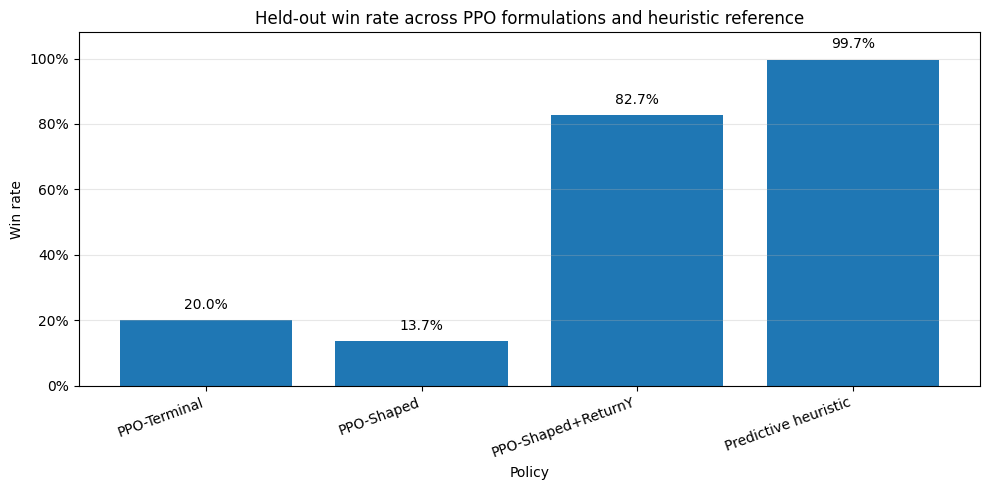

Saved: new_results\figures\fig_policy_comparison_win_rate.pdf


In [6]:
from matplotlib.ticker import PercentFormatter

plot_df = four_model_comparison_df.copy()
plt.figure(figsize=(10, 5))
bars = plt.bar(plot_df["policy"].astype(str), plot_df["win_rate"])
plt.ylabel("Win rate")
plt.xlabel("Policy")
plt.title("Held-out win rate across PPO formulations and heuristic reference")
plt.ylim(0, 1.08)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)

for bar, value in zip(bars, plot_df["win_rate"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.025,
        f"{100 * value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.tight_layout()
fig_path = os.path.join(FIG_DIR, "fig_policy_comparison_win_rate.pdf")
plt.savefig(fig_path, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")

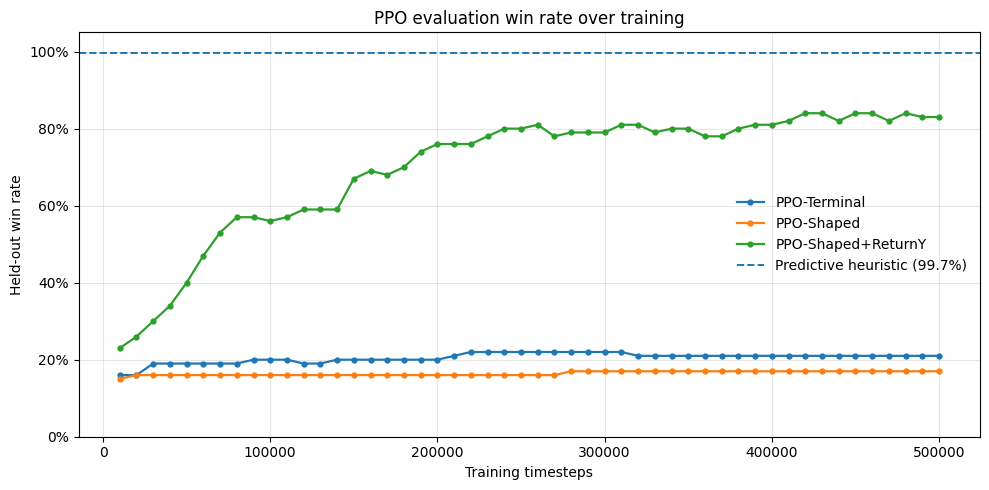

Saved: new_results\figures\fig_training_win_rate_comparison.pdf


In [7]:
history_parts = []
for experiment_key, experiment_cfg in EXPERIMENTS.items():
    history_df = PPO_EXPERIMENT_RESULTS[experiment_key]["history_df"].copy()
    history_df["policy"] = experiment_cfg["report_label"]
    history_parts.append(history_df)

ppo_training_history_df = pd.concat(history_parts, ignore_index=True)
heuristic_win_rate = float(heuristic_summary_df["win_rate"].iloc[0])
plt.figure(figsize=(10, 5))

for policy_name in [
    "PPO-Terminal",
    "PPO-Shaped",
    "PPO-Shaped+ReturnY",
]:
    policy_history = ppo_training_history_df.loc[
        ppo_training_history_df["policy"] == policy_name
    ]

    plt.plot(
        policy_history["timesteps"],
        policy_history["win_rate"],
        marker="o",
        linewidth=1.6,
        markersize=3.5,
        label=policy_name,
    )

plt.axhline(
    heuristic_win_rate,
    linestyle="--",
    linewidth=1.4,
    label=f"Predictive heuristic ({100 * heuristic_win_rate:.1f}%)",
)

plt.xlabel("Training timesteps")
plt.ylabel("Held-out win rate")
plt.title("PPO evaluation win rate over training")
plt.ylim(0, 1.05)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.grid(True, alpha=0.3)
plt.legend(frameon=False)
plt.tight_layout()
fig_path = os.path.join(FIG_DIR, "fig_training_win_rate_comparison.pdf")
plt.savefig(fig_path, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")

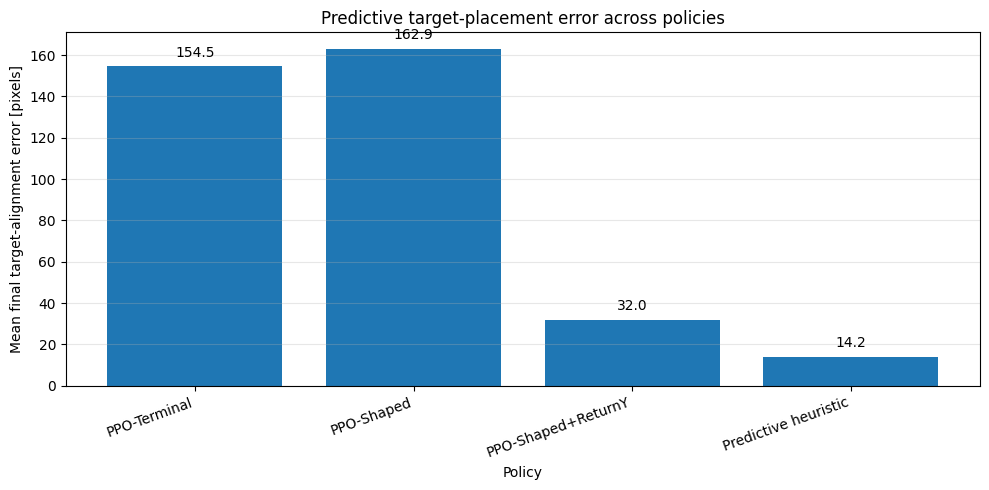

Saved: new_results\figures\fig_policy_comparison_alignment_error.pdf


In [8]:
plot_df = four_model_comparison_df.copy()
plt.figure(figsize=(10, 5))
bars = plt.bar(plot_df["policy"].astype(str), plot_df["mean_final_target_alignment_error"])
plt.ylabel("Mean final target-alignment error [pixels]")
plt.xlabel("Policy")
plt.title("Predictive target-placement error across policies")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)

for bar, value in zip(bars, plot_df["mean_final_target_alignment_error"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + max(plot_df["mean_final_target_alignment_error"]) * 0.02,
        f"{value:.1f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.tight_layout()
fig_path = os.path.join(FIG_DIR, "fig_policy_comparison_alignment_error.pdf")
plt.savefig(fig_path, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")

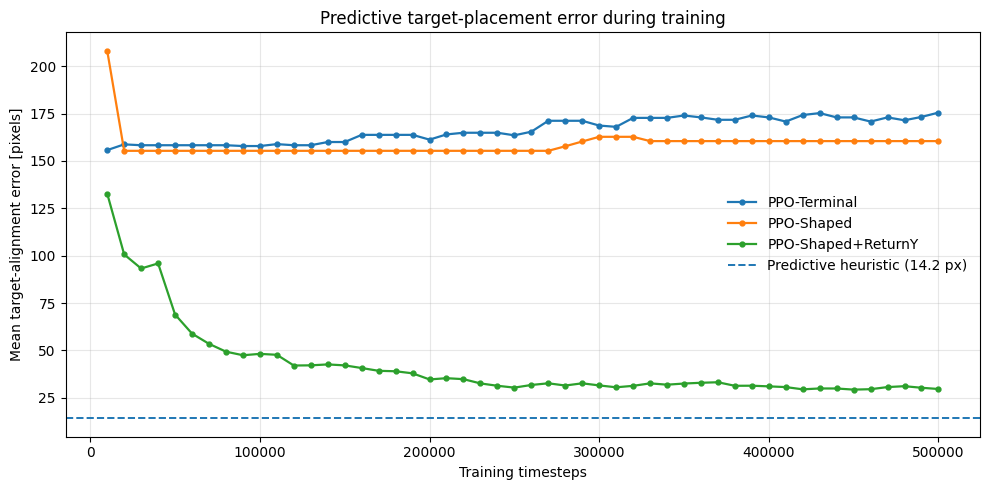

Saved: new_results\figures\fig_training_alignment_error_comparison.pdf


In [9]:
plt.figure(figsize=(10, 5))
for policy_name in [
    "PPO-Terminal",
    "PPO-Shaped",
    "PPO-Shaped+ReturnY",
]:
    policy_history = ppo_training_history_df.loc[
        ppo_training_history_df["policy"] == policy_name
    ]

    plt.plot(
        policy_history["timesteps"],
        policy_history["mean_final_target_alignment_error"],
        marker="o",
        linewidth=1.6,
        markersize=3.5,
        label=policy_name,
    )

heuristic_alignment_error = float(heuristic_summary_df["mean_final_target_alignment_error"].iloc[0])

plt.axhline(
    heuristic_alignment_error,
    linestyle="--",
    linewidth=1.4,
    label=f"Predictive heuristic ({heuristic_alignment_error:.1f} px)",
)

plt.xlabel("Training timesteps")
plt.ylabel("Mean target-alignment error [pixels]")
plt.title("Predictive target-placement error during training")
plt.grid(True, alpha=0.3)
plt.legend(frameon=False)
plt.tight_layout()
fig_path = os.path.join(FIG_DIR, "fig_training_alignment_error_comparison.pdf")
plt.savefig(fig_path, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")

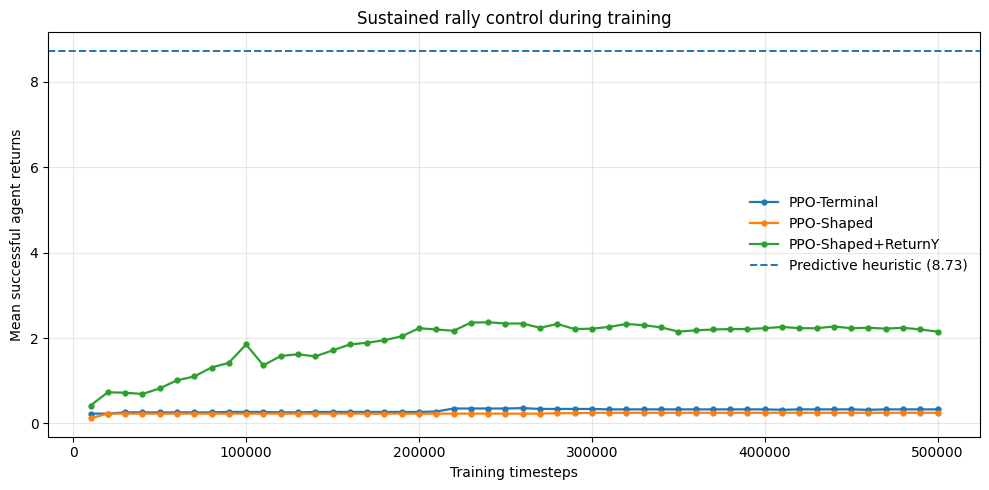

Saved: new_results\figures\fig_training_successful_returns_comparison.pdf


In [10]:
plt.figure(figsize=(10, 5))
for policy_name in [
    "PPO-Terminal",
    "PPO-Shaped",
    "PPO-Shaped+ReturnY",
]:
    policy_history = ppo_training_history_df.loc[
        ppo_training_history_df["policy"] == policy_name
    ]

    plt.plot(
        policy_history["timesteps"],
        policy_history["mean_successful_agent_returns"],
        marker="o",
        linewidth=1.6,
        markersize=3.5,
        label=policy_name,
    )

heuristic_returns = float(heuristic_summary_df["mean_successful_agent_returns"].iloc[0])

plt.axhline(
    heuristic_returns,
    linestyle="--",
    linewidth=1.4,
    label=f"Predictive heuristic ({heuristic_returns:.2f})",
)

plt.xlabel("Training timesteps")
plt.ylabel("Mean successful agent returns")
plt.title("Sustained rally control during training")
plt.grid(True, alpha=0.3)
plt.legend(frameon=False)
plt.tight_layout()
fig_path = os.path.join(FIG_DIR, "fig_training_successful_returns_comparison.pdf")
plt.savefig(fig_path, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")

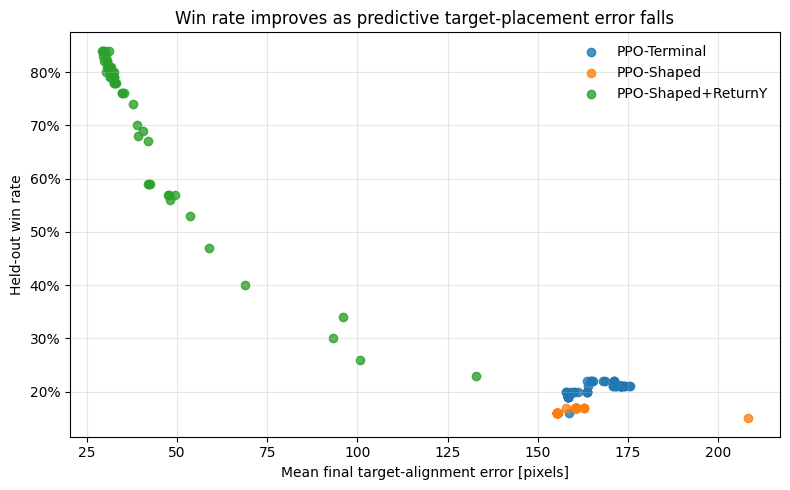

Saved: new_results\figures\fig_win_rate_vs_alignment_error.pdf


In [11]:
plt.figure(figsize=(8, 5))
for policy_name in [
    "PPO-Terminal",
    "PPO-Shaped",
    "PPO-Shaped+ReturnY",
]:
    policy_history = ppo_training_history_df.loc[
        ppo_training_history_df["policy"] == policy_name
    ]

    plt.scatter(
        policy_history["mean_final_target_alignment_error"],
        policy_history["win_rate"],
        label=policy_name,
        alpha=0.8,
    )

plt.xlabel("Mean final target-alignment error [pixels]")
plt.ylabel("Held-out win rate")
plt.title("Win rate improves as predictive target-placement error falls")
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.grid(True, alpha=0.3)
plt.legend(frameon=False)
plt.tight_layout()
fig_path = os.path.join(FIG_DIR, "fig_win_rate_vs_alignment_error.pdf")
plt.savefig(fig_path, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")

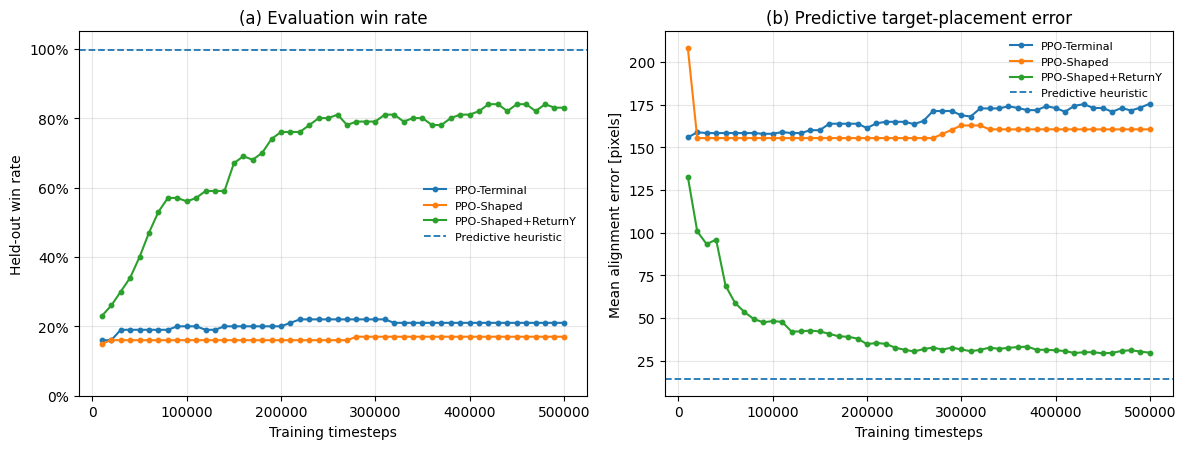

Saved: new_results\figures\fig_compact_training_diagnostics.pdf


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

for policy_name in [
    "PPO-Terminal",
    "PPO-Shaped",
    "PPO-Shaped+ReturnY",
]:
    policy_history = ppo_training_history_df.loc[ppo_training_history_df["policy"] == policy_name]

    axes[0].plot(
        policy_history["timesteps"],
        policy_history["win_rate"],
        marker="o",
        linewidth=1.5,
        markersize=3.2,
        label=policy_name,
    )

axes[0].axhline(
    heuristic_win_rate,
    linestyle="--",
    linewidth=1.3,
    label="Predictive heuristic",
)

axes[0].set_xlabel("Training timesteps")
axes[0].set_ylabel("Held-out win rate")
axes[0].set_title("(a) Evaluation win rate")
axes[0].set_ylim(0, 1.05)
axes[0].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[0].grid(True, alpha=0.3)
axes[0].legend(frameon=False, fontsize=8)

for policy_name in ["PPO-Terminal", "PPO-Shaped", "PPO-Shaped+ReturnY"]:
    policy_history = ppo_training_history_df.loc[ppo_training_history_df["policy"] == policy_name]

    axes[1].plot(
        policy_history["timesteps"],
        policy_history["mean_final_target_alignment_error"],
        marker="o",
        linewidth=1.5,
        markersize=3.2,
        label=policy_name,
    )

axes[1].axhline(
    heuristic_alignment_error,
    linestyle="--",
    linewidth=1.3,
    label="Predictive heuristic",
)

axes[1].set_xlabel("Training timesteps")
axes[1].set_ylabel("Mean alignment error [pixels]")
axes[1].set_title("(b) Predictive target-placement error")
axes[1].grid(True, alpha=0.3)
axes[1].legend(frameon=False, fontsize=8)
plt.tight_layout()
fig_path = os.path.join(FIG_DIR,"fig_compact_training_diagnostics.pdf")
plt.savefig(fig_path, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")